In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
from src.Propeller import Propeller
from src.JobParameters import AerodynamicParameters, AcousticParameters

with open("10x7E.pkl", "rb") as f:
    blade_dict = pickle.load(f)

In [2]:
aerodynamic_params = AerodynamicParameters(
    prop_radius=blade_dict['tip_radius'],
    hub_radius=blade_dict['hub_radius'],
    n_blades=blade_dict['n_blades'],
    rpm=7000,
    a_inf=343,
    rho=1.225,
    mu=1.81e-5,
)

acoustic_params = AcousticParameters(
    aero_params=aerodynamic_params,
    p_ref=2e-5, revolutions=100, num_obs_times_per_rev=100
)

v_inf = 0*np.ones(len(blade_dict['r']))

In [3]:
propeller = Propeller(
    propeller_geometry=blade_dict,
    aero_params=aerodynamic_params,
    acoustic_params=acoustic_params
)

propeller.run_bemt(v_inf=v_inf)

In [4]:
r_observer = np.array([[0, 1.88, 0]])
propeller.run_compact_f1a(observer_positions=r_observer, use_GPU=True)

In [5]:
import time
import torch
import numpy as np

def benchmark_propeller(propeller_obj, r_observer, n_iterations=10):
    print(f"Starting benchmark for {n_iterations} iterations...")
    
    # 1. Warm-up Iteration (Prevents skewed results from initial GPU memory allocation)
    propeller_obj.run_compact_f1a(observer_positions=r_observer, use_GPU=True)
    torch.cuda.synchronize()
    
    start_events = [torch.cuda.Event(enable_timing=True) for _ in range(n_iterations)]
    end_events = [torch.cuda.Event(enable_timing=True) for _ in range(n_iterations)]
    
    # 2. Timed Iterations
    cpu_start = time.perf_counter()
    
    for i in range(n_iterations):
        start_events[i].record()
        
        propeller_obj.run_compact_f1a(observer_positions=r_observer, use_GPU=True)
        
        end_events[i].record()

    # Wait for GPU to finish all tasks
    torch.cuda.synchronize()
    cpu_end = time.perf_counter()

    # 3. Calculate Results
    times = [s.elapsed_time(e) for s, e in zip(start_events, end_events)] # In milliseconds
    avg_time_ms = sum(times) / n_iterations
    total_cpu_time = (cpu_end - cpu_start) * 1000

    print("-" * 30)
    print(f"TIMING REPORT (GPU: {torch.cuda.get_device_name(0)})")
    print("-" * 30)
    print(f"Total iterations:  {n_iterations}")
    print(f"Average GPU Time:  {avg_time_ms:.2f} ms")
    print(f"Fastest Run:       {min(times):.2f} ms")
    print(f"Slowest Run:       {max(times):.2f} ms")
    print(f"Total Wall Time:   {total_cpu_time:.2f} ms")
    print("-" * 30)
    
    return times

In [6]:
timing_data = benchmark_propeller(propeller, r_observer, n_iterations=100)

Starting benchmark for 100 iterations...
------------------------------
TIMING REPORT (GPU: NVIDIA RTX PRO 500 Blackwell Generation Laptop GPU)
------------------------------
Total iterations:  100
Average GPU Time:  14.83 ms
Fastest Run:       12.09 ms
Slowest Run:       25.44 ms
Total Wall Time:   1484.09 ms
------------------------------


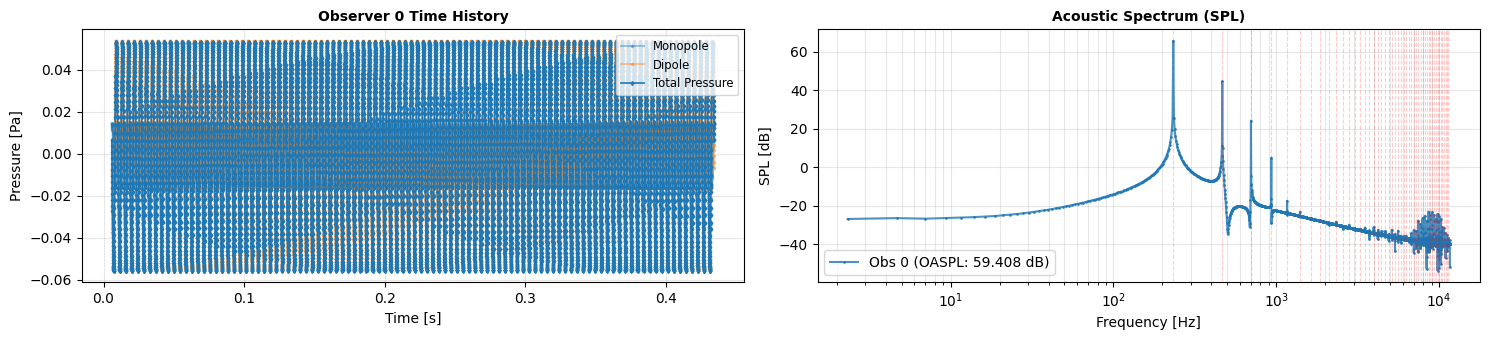

In [7]:
import matplotlib.gridspec as gridspec
                    
n_obs = r_observer.shape[0]
fig = plt.figure(figsize=(15, 3.5 * n_obs)) 
gs = gridspec.GridSpec(n_obs, 2, figure=fig)

fontsize = 10
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
blade_passing_freq = 1 / acoustic_params.blade_passing_period

ax_spl = fig.add_subplot(gs[:, 1])

for idx in range(n_obs):
    ax_time = fig.add_subplot(gs[idx, 0])
    color = colors[idx % len(colors)]
    
    ax_time.plot(propeller.t[:, idx], propeller.p_m[:, idx], 
                label='Monopole', linestyle='-', marker='o', markersize=1.5, alpha=0.4)
    ax_time.plot(propeller.t[:, idx], propeller.p_d[:, idx], 
                label='Dipole', linestyle='-', marker='s', markersize=1.5, alpha=0.4)
    ax_time.plot(propeller.t[:, idx], propeller.p_tot[:, idx], 
                color=color, linestyle='-', marker='d', markersize=2, 
                linewidth=1.2, label='Total Pressure')
    
    ax_time.set_title(f'Observer {idx} Time History', fontsize=fontsize, fontweight='bold')
    ax_time.set_xlabel('Time [s]', fontsize=fontsize)
    ax_time.set_ylabel('Pressure [Pa]', fontsize=fontsize)
    ax_time.grid(True, alpha=0.3)
    ax_time.legend(loc='upper right', fontsize='small')

    label_text = f'Obs {idx} (OASPL: {propeller.oaspl[idx]:.3f} dB)'
    
    ax_spl.semilogx(propeller.freq[1:, idx], propeller.spl[1:, idx], 
                    color=color, linestyle='-', marker='.', markersize=2, 
                    label=label_text, alpha=0.8)

ax_spl.set_title('Acoustic Spectrum (SPL)', fontsize=fontsize, fontweight='bold')
ax_spl.set_xlabel('Frequency [Hz]', fontsize=fontsize)
ax_spl.set_ylabel('SPL [dB]', fontsize=fontsize)

max_f = np.max(propeller.freq)
harmonic_freqs = np.arange(blade_passing_freq, max_f, blade_passing_freq)
for bpf in harmonic_freqs:
    ax_spl.axvline(bpf, color='red', linestyle='--', linewidth=0.8, alpha=0.2)

ax_spl.grid(True, which='both', alpha=0.3)
ax_spl.legend(fontsize=fontsize, loc='lower left')
ax_spl.set_ylim()
plt.tight_layout()
plt.show()